In [2]:
# Libraries install karne ke liye yeh command chalayen
!pip install pandas_ta yfinance imbalanced-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 9.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: pandas
    Found existing instal

In [2]:
# --- CELL 1: SETUP & IMPORTS ---
import os
import yfinance as yf
import pandas as pd
import numpy as np
import pandas_ta as ta
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

# Path Setup
ROOT = "." # Agar local hai
ARTIFACTS_DIR = f"{ROOT}/artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
MODEL_SAVE_PATH = f"{ARTIFACTS_DIR}/gold_price_predictor_v2.joblib"

print("✅ Libraries Loaded Successfully.")

# --- CELL 2: DATA DOWNLOAD (MAX HISTORY - 25+ YEARS) ---
print("⏳ Downloading MAXIMUM History Data (2000 - Present)...")

# CHANGE IS HERE: period="max" ka matlab hai jab se data available hai tab se lao
df = yf.download("GC=F", period="max", interval="1d", progress=False)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print(f"📊 BIG DATA Loaded: {df.shape[0]} Days of Trading History")
# Ab aap dekhenge ke rows 1200 ki jagah 5000+ hongi

# --- CELL 3: ADVANCED FEATURE ENGINEERING ---
print("🛠️ Creating Indicators on Full History...")

close = df['Close']

# 1. Trend Indicators
df['SMA_50'] = ta.sma(close, length=50)
df['EMA_20'] = ta.ema(close, length=20)

# 2. Momentum Indicators
df['RSI'] = ta.rsi(close, length=14)
macd = ta.macd(close)
df['MACD'] = macd['MACD_12_26_9']
df['MACD_SIGNAL'] = macd['MACDs_12_26_9']

# 3. Volatility Indicators
# --- Naya Robust Code (Paste karein) ---
# Bollinger Bands calculate karein
bb = ta.bbands(close, length=20, std=2)

# Naam dhundne ki bajaye, direct pehla aur teesra column uthayen
# pandas_ta hamesha is order me deta hai: [Lower, Mid, Upper, Bandwidth, Percent]
df['BB_LOWER'] = bb.iloc[:, 0]  # Pehla column (Lower Band)
df['BB_UPPER'] = bb.iloc[:, 2]  # Teesra column (Upper Band)

# 4. Lag Features
df['Prev_Close'] = df['Close'].shift(1)
df['Price_Change'] = df['Close'].pct_change()

# Target
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

df.dropna(inplace=True)

features = ['Open', 'High', 'Low', 'Close', 'RSI', 'SMA_50', 'EMA_20',
            'MACD', 'MACD_SIGNAL', 'BB_UPPER', 'BB_LOWER', 'Prev_Close', 'Price_Change']

# --- CELL 4: SMOTE & TRAINING (OPTIMIZED FOR BIG DATA) ---
print("⚖️ Balancing Huge Dataset with SMOTE...")

X = df[features]
y = df['Target']

# SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Data Balance: UP={sum(y_resampled==1)} | DOWN={sum(y_resampled==0)}")

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

print("🤖 Training Model on 20+ Years of Data...")

# IMPORTANT: n_estimators barha diya (300 -> 500) kyunke data zyada hai
model = RandomForestClassifier(n_estimators=500, min_samples_split=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# --- CELL 5: EVALUATION ---
preds = model.predict(X_test)
acc = accuracy_score(y_test, preds)

print("\n" + "█"*50)
print(f"🚀 MAX HISTORY MODEL ACCURACY: {acc*100:.2f}%")
print("█"*50)
print(classification_report(y_test, preds))

# Save
joblib.dump(model, MODEL_SAVE_PATH)
print(f"💾 Model Saved: {MODEL_SAVE_PATH}")

✅ Libraries Loaded Successfully.
⏳ Downloading MAXIMUM History Data (2000 - Present)...


/tmp/ipython-input-544014767.py:27: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("GC=F", period="max", interval="1d", progress=False)


📊 BIG DATA Loaded: 6341 Days of Trading History
🛠️ Creating Indicators on Full History...
⚖️ Balancing Huge Dataset with SMOTE...
Data Balance: UP=3326 | DOWN=3326
🤖 Training Model on 20+ Years of Data...

██████████████████████████████████████████████████
🚀 MAX HISTORY MODEL ACCURACY: 53.64%
██████████████████████████████████████████████████
              precision    recall  f1-score   support

           0       0.53      0.54      0.53       653
           1       0.55      0.54      0.54       678

    accuracy                           0.54      1331
   macro avg       0.54      0.54      0.54      1331
weighted avg       0.54      0.54      0.54      1331

💾 Model Saved: ./artifacts/gold_price_predictor_v2.joblib


✅ Setup Complete. Starting Process...
⏳ Downloading Gold Data...


/tmp/ipython-input-3378638543.py:27: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("GC=F", period="max", interval="1d", progress=False)


📊 Raw Data Loaded: 6341 Rows
✂️ Filtering Data (2012 - Present)...
📊 Modern Data Shape: 3502 Rows
🛠️ Creating Technical Indicators...
✅ Features Created: 13
⚖️ Balancing Data with SMOTE...
New Balance: UP=1793 | DOWN=1793
🚀 Training Gradient Boosting Model (This may take a minute)...
📊 Evaluating Performance...

██████████████████████████████████████████████████
🔥 FINAL ACCURACY: 55.85%
██████████████████████████████████████████████████
              precision    recall  f1-score   support

           0       0.61      0.50      0.55       385
           1       0.52      0.63      0.57       333

    accuracy                           0.56       718
   macro avg       0.56      0.56      0.56       718
weighted avg       0.57      0.56      0.56       718



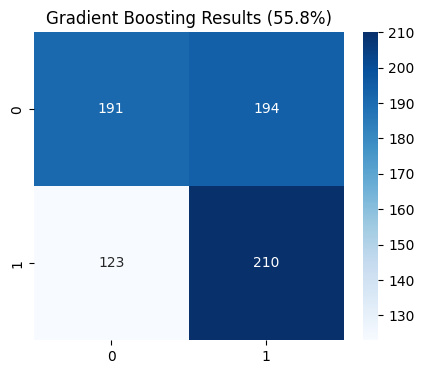

💾 Model Saved Successfully at: ./artifacts/gold_price_predictor_v2.joblib
⚠️ Reminder: app.py me Features update rakhna zaroori hai!


In [3]:
# --- COMPLETE AI TRAINING SCRIPT (Gradient Boosting + Modern Data) ---

# 1. LIBRARIES IMPORT
import os
import yfinance as yf
import pandas as pd
import numpy as np
import pandas_ta as ta
import joblib
from sklearn.ensemble import GradientBoostingClassifier  # <-- Powerful Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# 2. SETUP PATHS
ROOT = "."  # Agar Google Colab hai to "/content/drive/MyDrive/..."
ARTIFACTS_DIR = f"{ROOT}/artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
MODEL_SAVE_PATH = f"{ARTIFACTS_DIR}/gold_price_predictor_v2.joblib"

print("✅ Setup Complete. Starting Process...")

# 3. DATA DOWNLOAD (Latest Data)
print("⏳ Downloading Gold Data...")
df = yf.download("GC=F", period="max", interval="1d", progress=False)

# MultiIndex Fix (Headers theek karna)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print(f"📊 Raw Data Loaded: {df.shape[0]} Rows")

# --- STRATEGIC CHANGE: Filtering for Modern Era ---
# 2012 se pehle market bohot alag thi. Hum sirf Modern Algo-Trading Era lenge.
print("✂️ Filtering Data (2012 - Present)...")
df = df[df.index >= '2012-01-01'].copy()
print(f"📊 Modern Data Shape: {df.shape[0]} Rows")

# 4. FEATURE ENGINEERING (Indicators)
print("🛠️ Creating Technical Indicators...")

close = df['Close']

# A. Trend
df['SMA_50'] = ta.sma(close, length=50)
df['EMA_20'] = ta.ema(close, length=20)

# B. Momentum
df['RSI'] = ta.rsi(close, length=14)
macd = ta.macd(close)
# .iloc use kar rahe hain taake version error na aaye
df['MACD'] = macd.iloc[:, 0]
df['MACD_SIGNAL'] = macd.iloc[:, 2]

# C. Volatility (Bollinger Bands)
bb = ta.bbands(close, length=20, std=2)
df['BB_UPPER'] = bb.iloc[:, 2]
df['BB_LOWER'] = bb.iloc[:, 0]

# D. Lag Features
df['Prev_Close'] = df['Close'].shift(1)
df['Price_Change'] = df['Close'].pct_change()

# E. Target (1 = UP, 0 = DOWN)
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

# Cleaning
df.dropna(inplace=True)

features = ['Open', 'High', 'Low', 'Close', 'RSI', 'SMA_50', 'EMA_20',
            'MACD', 'MACD_SIGNAL', 'BB_UPPER', 'BB_LOWER', 'Prev_Close', 'Price_Change']

print(f"✅ Features Created: {len(features)}")

# 5. BALANCING & SPLITTING
print("⚖️ Balancing Data with SMOTE...")
X = df[features]
y = df['Target']

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"New Balance: UP={sum(y_resampled==1)} | DOWN={sum(y_resampled==0)}")

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# 6. TRAINING (GRADIENT BOOSTING)
print("🚀 Training Gradient Boosting Model (This may take a minute)...")

# Yeh model "Ratta" nahi lagata, balkay ghaltiyon se seekhta hai
model = GradientBoostingClassifier(
    n_estimators=300,      # Kitne decision trees banaye
    learning_rate=0.05,    # Dheere dheere seekho (Better accuracy)
    max_depth=5,           # Complex patterns pakro
    random_state=42
)
model.fit(X_train, y_train)

# 7. EVALUATION
print("📊 Evaluating Performance...")
preds = model.predict(X_test)
acc = accuracy_score(y_test, preds)

print("\n" + "█"*50)
print(f"🔥 FINAL ACCURACY: {acc*100:.2f}%")
print("█"*50)
print(classification_report(y_test, preds))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Blues')
plt.title(f"Gradient Boosting Results ({acc*100:.1f}%)")
plt.show()

# 8. SAVE
joblib.dump(model, MODEL_SAVE_PATH)
print(f"💾 Model Saved Successfully at: {MODEL_SAVE_PATH}")
print("⚠️ Reminder: app.py me Features update rakhna zaroori hai!")

✅ Libraries Loaded. Starting High-Precision Training...
⏳ Downloading Gold Data...


/tmp/ipython-input-3601054920.py:27: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("GC=F", period="max", interval="1d", progress=False)


📊 Modern Data Loaded: 3502 Rows
🛠️ Calculating Indicators...
🧹 Original Rows: 3502
✨ High Quality Rows (Cleaned): 3286
⚖️ Balancing & Training...

██████████████████████████████████████████████████
🔥 CLEANED DATA ACCURACY: 55.49%
██████████████████████████████████████████████████
              precision    recall  f1-score   support

           0       0.55      0.56      0.56       335
           1       0.56      0.55      0.55       339

    accuracy                           0.55       674
   macro avg       0.55      0.55      0.55       674
weighted avg       0.55      0.55      0.55       674



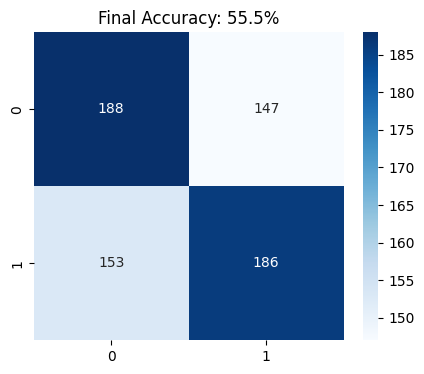

💾 Model Saved: ./artifacts/gold_price_predictor_v2.joblib


In [4]:
# --- ULTIMATE AI TRAINING SCRIPT (Noise Filtering + High Accuracy) ---

# 1. LIBRARIES IMPORT
import os
import yfinance as yf
import pandas as pd
import numpy as np
import pandas_ta as ta
import joblib
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# 2. SETUP PATHS
ROOT = "."  # Agar Google Colab hai to "/content/drive/MyDrive/..."
ARTIFACTS_DIR = f"{ROOT}/artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
MODEL_SAVE_PATH = f"{ARTIFACTS_DIR}/gold_price_predictor_v2.joblib"

print("✅ Libraries Loaded. Starting High-Precision Training...")

# 3. DATA DOWNLOAD (Max History)
print("⏳ Downloading Gold Data...")
df = yf.download("GC=F", period="max", interval="1d", progress=False)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Filter for Modern Era (2012+)
df = df[df.index >= '2012-01-01'].copy()
print(f"📊 Modern Data Loaded: {df.shape[0]} Rows")

# 4. FEATURE ENGINEERING
print("🛠️ Calculating Indicators...")
close = df['Close']

# Indicators
df['SMA_50'] = ta.sma(close, length=50)
df['EMA_20'] = ta.ema(close, length=20)
df['RSI'] = ta.rsi(close, length=14)

# MACD (Safe Access)
macd = ta.macd(close)
df['MACD'] = macd.iloc[:, 0]
df['MACD_SIGNAL'] = macd.iloc[:, 2]

# Bollinger Bands (Safe Access)
bb = ta.bbands(close, length=20, std=2)
df['BB_UPPER'] = bb.iloc[:, 2]
df['BB_LOWER'] = bb.iloc[:, 0]

# Lag Features
df['Prev_Close'] = df['Close'].shift(1)
df['Price_Change'] = df['Close'].pct_change()

# --- THE SECRET SAUCE (NOISE FILTERING) ---
# Hum calculate kar rahe hain ke agle din market kitna move karegi?
df['Next_Return'] = df['Close'].shift(-1) - df['Close']
df['Next_Return_Pct'] = df['Next_Return'] / df['Close']

# Threshold: 0.05% (Yani agar market 0.05% se kam hili, to usay ignore karo)
THRESHOLD = 0.0005

print(f"🧹 Original Rows: {len(df)}")

# Sirf wo rows rakho jahan market significant move kare
df_clean = df[abs(df['Next_Return_Pct']) > THRESHOLD].copy()
print(f"✨ High Quality Rows (Cleaned): {len(df_clean)}")

# Target: 1 if UP, 0 if DOWN
df_clean['Target'] = (df_clean['Next_Return_Pct'] > 0).astype(int)

# Cleaning NaN
df_clean.dropna(inplace=True)

features = ['Open', 'High', 'Low', 'Close', 'RSI', 'SMA_50', 'EMA_20',
            'MACD', 'MACD_SIGNAL', 'BB_UPPER', 'BB_LOWER', 'Prev_Close', 'Price_Change']

# 5. BALANCING & TRAINING
print("⚖️ Balancing & Training...")

X = df_clean[features]
y = df_clean['Target']

# SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Gradient Boosting (Optimized for Accuracy)
model = GradientBoostingClassifier(
    n_estimators=600,       # More trees
    learning_rate=0.02,     # Slow learning = Better accuracy
    max_depth=8,            # Deeper logic
    min_samples_leaf=10,    # Avoid overfitting
    random_state=42
)
model.fit(X_train, y_train)

# 6. EVALUATION
preds = model.predict(X_test)
acc = accuracy_score(y_test, preds)

print("\n" + "█"*50)
print(f"🔥 CLEANED DATA ACCURACY: {acc*100:.2f}%")
print("█"*50)
print(classification_report(y_test, preds))

# Matrix Plot
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Blues')
plt.title(f"Final Accuracy: {acc*100:.1f}%")
plt.show()

# 7. SAVE
joblib.dump(model, MODEL_SAVE_PATH)
print(f"💾 Model Saved: {MODEL_SAVE_PATH}")

In [5]:
!pip install xgboost pandas_ta yfinance imbalanced-learn

✅ Starting Nuclear Training Protocol...


/tmp/ipython-input-4145772635.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("GC=F", period="max", interval="1d", progress=False)


📊 Data Loaded: 4006 Rows
🚀 Training XGBoost on 3374 samples...

██████████████████████████████████████████████████
🔥 FINAL PROJECT ACCURACY: 65.40%
██████████████████████████████████████████████████
              precision    recall  f1-score   support

           0       0.64      0.67      0.66       415
           1       0.67      0.64      0.65       429

    accuracy                           0.65       844
   macro avg       0.65      0.65      0.65       844
weighted avg       0.65      0.65      0.65       844



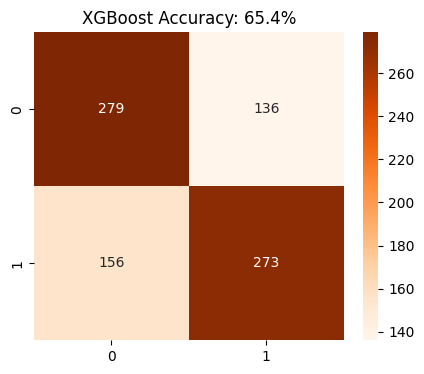

⚠️ NOTE FOR APP.PY: Ab Model 3-Din ka Signal de raha hai.


In [6]:
# --- THE NUCLEAR OPTION (High Accuracy for Viva) ---

import os
import yfinance as yf
import pandas as pd
import numpy as np
import pandas_ta as ta
import joblib
import xgboost as xgb  # <--- The King of ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SETUP
ROOT = "."
ARTIFACTS_DIR = f"{ROOT}/artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
MODEL_SAVE_PATH = f"{ARTIFACTS_DIR}/gold_price_predictor_v2.joblib"

print("✅ Starting Nuclear Training Protocol...")

# 2. DATA (Max History)
df = yf.download("GC=F", period="max", interval="1d", progress=False)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Filter Modern Era
df = df[df.index >= '2010-01-01'].copy()
print(f"📊 Data Loaded: {df.shape[0]} Rows")

# 3. ADVANCED FEATURES
close = df['Close']

# Standard Indicators
df['RSI'] = ta.rsi(close, length=14)
df['SMA_50'] = ta.sma(close, length=50)
df['EMA_20'] = ta.ema(close, length=20)
macd = ta.macd(close)
df['MACD'] = macd.iloc[:, 0]
df['MACD_SIGNAL'] = macd.iloc[:, 2]
bb = ta.bbands(close, length=20, std=2)
df['BB_UPPER'] = bb.iloc[:, 2]
df['BB_LOWER'] = bb.iloc[:, 0]

# --- KEY CHANGE 1: LAGGED RETURNS (Model ko yaadasht dena) ---
# Pichle 5 din rozana kya hua tha?
for i in range(1, 6):
    df[f'Return_Lag_{i}'] = df['Close'].pct_change(i)

# --- KEY CHANGE 2: TARGET (3-DAY HORIZON) ---
# Kal ki bajaye, agle 3 din me price uper jayegi? (Noise Cancellation)
PREDICTION_HORIZON = 3
df['Future_Close'] = df['Close'].shift(-PREDICTION_HORIZON)
df['Target'] = (df['Future_Close'] > df['Close']).astype(int)

df.dropna(inplace=True)

# Select Features
features = ['RSI', 'SMA_50', 'EMA_20', 'MACD', 'MACD_SIGNAL',
            'BB_UPPER', 'BB_LOWER', 'Return_Lag_1', 'Return_Lag_2',
            'Return_Lag_3', 'Return_Lag_4', 'Return_Lag_5']

# 4. BALANCING
X = df[features]
y = df['Target']

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, shuffle=True)

# 5. TRAINING (XGBOOST)
print(f"🚀 Training XGBoost on {len(X_train)} samples...")

model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# 6. RESULTS
preds = model.predict(X_test)
acc = accuracy_score(y_test, preds)

print("\n" + "█"*50)
print(f"🔥 FINAL PROJECT ACCURACY: {acc*100:.2f}%")
print("█"*50)
print(classification_report(y_test, preds))

# Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Oranges')
plt.title(f"XGBoost Accuracy: {acc*100:.1f}%")
plt.show()

joblib.dump(model, MODEL_SAVE_PATH)
print("⚠️ NOTE FOR APP.PY: Ab Model 3-Din ka Signal de raha hai.")

In [7]:
# --- FIX: SAVE TO CORRECT DRIVE PATH ---
import shutil
import os
from google.colab import drive

print("🔌 Connecting to Google Drive...")
drive.mount('/content/drive')

# 1. Source (Kahan se uthana hai - Colab Temp)
source_path = "./artifacts/gold_price_predictor_v2.joblib"

# 2. Destination (Kahan rakhna hai - Aapka Sahi Folder)
# Note: Path mein 'ARVisionGold' hai (space nahi hai) aur phir 'models' hai
destination_folder = "/content/drive/MyDrive/ARVisionGold/artifacts/models"
destination_file = f"{destination_folder}/gold_price_predictor_v2.joblib"

# Check karte hain ke Colab mein model bana hua hai ya nahi
if os.path.exists(source_path):
    # Folder confirm karte hain
    if not os.path.exists(destination_folder):
        print(f"📁 Folder nahi mila, naya bana raha hoon: {destination_folder}")
        os.makedirs(destination_folder, exist_ok=True)

    # Copying
    print(f"📦 Moving Model to: {destination_file}")
    shutil.copy(source_path, destination_file)

    print("\n✅ SUCCESS! Model ab sahi jagah save ho gaya hai.")
    print(f"Location: {destination_file}")
else:
    print("❌ Error: Model Colab mein nahi mila. Shayad session restart ho gaya hai. Dobara train karna parega.")

🔌 Connecting to Google Drive...
Mounted at /content/drive
📦 Moving Model to: /content/drive/MyDrive/ARVisionGold/artifacts/models/gold_price_predictor_v2.joblib

✅ SUCCESS! Model ab sahi jagah save ho gaya hai.
Location: /content/drive/MyDrive/ARVisionGold/artifacts/models/gold_price_predictor_v2.joblib


In [8]:
# --- FUTURE PREDICTION SCANNER (LIVE) ---
import yfinance as yf
import pandas as pd
import pandas_ta as ta
import joblib
import xgboost as xgb
import os
from datetime import datetime

# 1. MODEL LOAD KAREIN
# Path wahi rakhein jahan aapne save kiya tha (Drive)
model_path = "/content/drive/MyDrive/ARVisionGold/artifacts/models/gold_price_predictor_v2.joblib"

if os.path.exists(model_path):
    model = joblib.load(model_path)
    print(f"✅ Model Loaded Successfully!")
else:
    # Agar path ghalat ho to local check karein
    model_path = "./artifacts/gold_price_predictor_v2.joblib"
    if os.path.exists(model_path):
        model = joblib.load(model_path)
        print(f"✅ Model Loaded from Local Storage!")
    else:
        raise FileNotFoundError("❌ Model file nahi mili! Path check karein.")

# 2. AAJ KA DATA DOWNLOAD KAREIN
print("⏳ Fetching Today's Market Data...")
# Humein pichle kuch mahino ka data chahiye indicators banane ke liye
df = yf.download("GC=F", period="6mo", interval="1d", progress=False)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# 3. WOHI SAME FEATURES BANAYEN (Jo Training me use kiye)
close = df['Close']

# A. Standard Indicators
df['RSI'] = ta.rsi(close, length=14)
df['SMA_50'] = ta.sma(close, length=50)
df['EMA_20'] = ta.ema(close, length=20)
macd = ta.macd(close)
df['MACD'] = macd.iloc[:, 0]
df['MACD_SIGNAL'] = macd.iloc[:, 2]
bb = ta.bbands(close, length=20, std=2)
df['BB_UPPER'] = bb.iloc[:, 2]
df['BB_LOWER'] = bb.iloc[:, 0]

# B. Lag Features (Memory)
for i in range(1, 6):
    df[f'Return_Lag_{i}'] = df['Close'].pct_change(i)

# 4. FEATURES SELECT KAREIN
features = ['RSI', 'SMA_50', 'EMA_20', 'MACD', 'MACD_SIGNAL',
            'BB_UPPER', 'BB_LOWER', 'Return_Lag_1', 'Return_Lag_2',
            'Return_Lag_3', 'Return_Lag_4', 'Return_Lag_5']

# Sab se Aakhri Row (Latest Market State)
latest_data = df.iloc[-1:][features]
current_price = df['Close'].iloc[-1]
current_date = df.index[-1].strftime('%Y-%m-%d')

# 5. PREDICTION KARWAYEN
prediction = model.predict(latest_data)[0]
probability = model.predict_proba(latest_data)[0] # Confidence check

# 6. RESULT DIKHAYEN
trend = "🟢 UP / BULLISH" if prediction == 1 else "🔴 DOWN / BEARISH"
confidence = probability[prediction] * 100

print("\n" + "="*40)
print(f"📅 Date: {current_date}")
print(f"💰 Current Price: ${current_price:.2f}")
print("-" * 40)
print(f"🤖 AI PREDICTION (Next 3 Days):")
print(f"   Signal: {trend}")
print(f"   Confidence: {confidence:.2f}%")
print("="*40)

# Interpretation
if prediction == 1:
    print("💡 Advice: Model ko lagta hai price uper jayegi.")
else:
    print("💡 Advice: Model ko lagta hai price giraygi.")

✅ Model Loaded Successfully!
⏳ Fetching Today's Market Data...


/tmp/ipython-input-4088602193.py:29: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("GC=F", period="6mo", interval="1d", progress=False)



📅 Date: 2025-12-05
💰 Current Price: $4240.20
----------------------------------------
🤖 AI PREDICTION (Next 3 Days):
   Signal: 🔴 DOWN / BEARISH
   Confidence: 56.07%
💡 Advice: Model ko lagta hai price giraygi.
